# 2 - Análise do modelo em produção

In [34]:
import pandas as pd
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.utils import resample
import numpy as np
import matplotlib.pyplot as plt

Inicialmente, podemos calcular a acurácia do modelo A, uma métrica bem ingênua mas que gera algum indicativo inicial.

In [16]:
dados = pd.read_csv('../dados/chamados_com_predicoes.csv', index_col='id_chamado')

In [17]:
acertos =  dados[dados['categoria_real'] == dados['pred_modelo_a']]

In [18]:
acuracia_modelo_a = len(acertos) / len(dados)
print(f"Acurácia do Modelo A: {acuracia_modelo_a:.2%}")

Acurácia do Modelo A: 77.28%


Mas como temos um dataset desbalanceado, a acurácia pode simplesmente ignorar erros muito grandes em classes menos representadas.

Por isso, estarei utilizando a métrica de F1-Score por categoria, utilizando bootstraping para calcular o intervalo de confiança.

In [19]:
y_true = dados["categoria_real"]
y_pred = dados["pred_modelo_a"]

In [20]:
print(classification_report(y_true, y_pred, zero_division=0))

                          precision    recall  f1-score   support

     barulho_perturbacao       0.80      0.78      0.79       400
              buraco_via       0.66      0.82      0.73       908
             coleta_lixo       0.81      0.81      0.81       806
        esgoto_vazamento       0.71      0.58      0.64       621
estacionamento_irregular       0.80      0.83      0.81       437
      iluminacao_publica       0.86      0.79      0.82      1143
             poda_arvore       0.80      0.78      0.79       458
             sinalizacao       0.74      0.80      0.77       227

                accuracy                           0.77      5000
               macro avg       0.77      0.77      0.77      5000
            weighted avg       0.78      0.77      0.77      5000



Como susposto, o modelo A performa melhor na classe mais representativa. 

Inclusive ele possui uma alta precisão na classe de iluminacao_publica, mostrando possivelmente algum vício em classificar os chamados em iluminacao_publica sendo ela a mais representativa.

In [27]:
def bootstrap_f1(y_true, y_pred, labels, n_boot=2000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    n_labels = len(labels)
    boot_precision = np.zeros((n_boot, n_labels))
    boot_recall = np.zeros((n_boot, n_labels))
    boot_f1 = np.zeros((n_boot, n_labels))
    boot_macro_f1 = np.zeros(n_boot)
    
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        yt_sample = y_true[idx]
        yp_sample = y_pred[idx]
        
        p, r, f1, _ = precision_recall_fscore_support(yt_sample, yp_sample, average=None, labels=labels, zero_division=0)
        boot_precision[i, :] = p
        boot_recall[i, :] = r
        boot_f1[i, :] = f1
    
    alpha = (1 - ci) / 2
    resultados = {}
    
    for j, categoria in enumerate(labels):
        valores_f1 = boot_f1[:, j]
        valores_precision = boot_precision[:, j]
        valores_recall = boot_recall[:, j]
        
        resultados[categoria] = {
            "f1_medio": valores_f1.mean(),
            "ic_lower_f1": np.percentile(valores_f1, alpha * 100),
            "ic_upper_f1": np.percentile(valores_f1, (1 - alpha) * 100),
            "precision_medio": valores_precision.mean(),
            "ic_lower_precision": np.percentile(valores_precision, alpha * 100),
            "ic_upper_precision": np.percentile(valores_precision, (1 - alpha) * 100),
            "recall_medio": valores_recall.mean(),
            "ic_lower_recall": np.percentile(valores_recall, alpha * 100),
            "ic_upper_recall": np.percentile(valores_recall, (1 - alpha) * 100)
        }
    
    resultados["macro_avg"] = {
        "f1_medio": boot_macro_f1.mean(),
        "ic_lower": np.percentile(boot_macro_f1, alpha * 100),
        "ic_upper": np.percentile(boot_macro_f1, (1 - alpha) * 100)
    }
    
    return resultados

In [30]:
labels = sorted(dados["categoria_real"].unique())
resultados = bootstrap_f1(dados["categoria_real"], dados["pred_modelo_a"], labels)

for categoria in labels:
    stats = resultados[categoria]
    print(f"\n{categoria}:")
    print(f"  Precision: {stats["precision_medio"]:.3f} "
          f"IC95%=[{stats['ic_lower_precision']:.3f}, {stats["ic_upper_precision"]:.3f}]")
    print(f"  Recall:    {stats['recall_medio']:.3f} "
          f"IC95%=[{stats['ic_lower_recall']:.3f}, {stats['ic_upper_recall']:.3f}]")
    print(f"  F1:        {stats['f1_medio']:.3f} "
          f"IC95%=[{stats['ic_lower_f1']:.3f}, {stats['ic_upper_f1']:.3f}]")


barulho_perturbacao:
  Precision: 0.801 IC95%=[0.761, 0.838]
  Recall:    0.775 IC95%=[0.732, 0.817]
  F1:        0.788 IC95%=[0.756, 0.819]

buraco_via:
  Precision: 0.664 IC95%=[0.635, 0.692]
  Recall:    0.817 IC95%=[0.792, 0.841]
  F1:        0.732 IC95%=[0.710, 0.755]

coleta_lixo:
  Precision: 0.814 IC95%=[0.787, 0.843]
  Recall:    0.806 IC95%=[0.779, 0.832]
  F1:        0.810 IC95%=[0.789, 0.831]

esgoto_vazamento:
  Precision: 0.711 IC95%=[0.673, 0.749]
  Recall:    0.578 IC95%=[0.538, 0.617]
  F1:        0.637 IC95%=[0.605, 0.670]

estacionamento_irregular:
  Precision: 0.800 IC95%=[0.762, 0.837]
  Recall:    0.826 IC95%=[0.790, 0.859]
  F1:        0.812 IC95%=[0.784, 0.840]

iluminacao_publica:
  Precision: 0.857 IC95%=[0.835, 0.878]
  Recall:    0.792 IC95%=[0.769, 0.815]
  F1:        0.824 IC95%=[0.806, 0.842]

poda_arvore:
  Precision: 0.804 IC95%=[0.766, 0.840]
  Recall:    0.776 IC95%=[0.737, 0.813]
  F1:        0.789 IC95%=[0.759, 0.817]

sinalizacao:
  Precision: 0.7

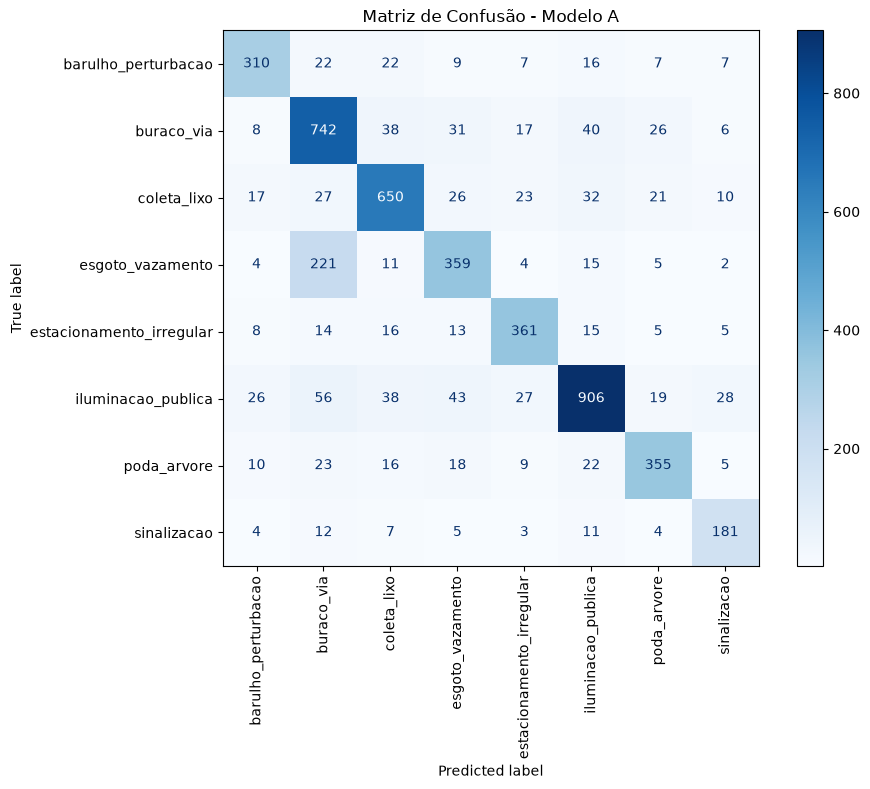

In [41]:
cm = confusion_matrix(dados["categoria_real"], dados["pred_modelo_a"], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", values_format='d')
plt.title("Matriz de Confusão - Modelo A")
plt.tight_layout()
plt.show()

In [42]:
def acuracia_por_categoria(feature, dados):
    labels = dados[feature].unique()
    acuracias = {}
    for categoria in labels:
        dados_categoria = dados[dados[feature] == categoria]
        acertos_categoria = dados_categoria[dados_categoria["pred_modelo_a"] == dados_categoria["categoria_real"]]
        acuracia = acertos_categoria.shape[0] / dados_categoria.shape[0]
        acuracias[categoria] = acuracia
    return acuracias

In [44]:
acuracia_por_categoria("canal", dados)

{'app_1746': 0.7641196013289037,
 'telefone_1746': 0.781322505800464,
 'portal_web': 0.7799539170506913}

In [45]:
acuracia_por_categoria("bairro", dados)

{'Botafogo': 0.7851851851851852,
 'Ilha do Governador': 0.7943262411347518,
 'Campo Grande': 0.7823639774859287,
 'Tijuca': 0.7674418604651163,
 'Penha': 0.7474226804123711,
 'Méier': 0.7286245353159851,
 'Barra da Tijuca': 0.771712158808933,
 'Realengo': 0.7833935018050542,
 'Bangu': 0.7885057471264367,
 'Santa Cruz': 0.7569832402234636,
 'Jacarepaguá': 0.7858672376873662,
 'Irajá': 0.7859778597785978,
 'Copacabana': 0.7885714285714286,
 'Madureira': 0.75,
 'Centro': 0.760655737704918}